# Yoruba HapMap (Pickrell 2010): R limma vs pylimma parity

This notebook runs the pylimma `voom (scaling stress)` pipeline live on the Pickrell Yoruba RNA-seq dataset and compares the output against pre-computed R limma results.

**Dataset**: 38,415 genes x 69 individuals. Contrast: male vs female. Largest real dataset in the suite - stresses the per-gene inner loops in both implementations.

**Pipeline**: `voom` -> `lm_fit` -> `contrasts_fit` -> `e_bayes` -> `top_table`

**R reference**: the CSV in `data/R_references/yoruba_toptable.csv.gz` was produced once by `data/_setup_R_references.R` on R 4.2.3 with limma 3.54.2. The `VERSIONS.txt` sidecar records the exact toolchain.

The notebook loads both the dataset and the R reference from the committed CSVs. No R installation is required to run it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add the repository root to sys.path so `pylimma` and the
# `data/generate_data.py` helper are importable when running
# this notebook directly from `examples/`.
REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "data"))

import generate_data as gd

import pylimma

DATA_DIR = REPO / "data"
R_REF    = DATA_DIR / "R_references"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 10)

## 1. Load the data and the R reference

In [2]:
data = gd.load_yoruba()
counts  = data["counts"]
targets = data["targets"]
print(f"counts matrix: {counts.shape}")
print(targets.head())
print(f"\ngender breakdown:\n{targets['gender'].value_counts()}")

r_ref = pd.read_csv(R_REF / "yoruba_toptable.csv.gz").set_index("GeneID")
print(f"\nR reference top-table: {r_ref.shape}")
r_ref.head()

counts matrix: (38415, 69)
         num.tech.reps population     study  gender
NA18486              2        YRI  Pickrell    male
NA18498              2        YRI  Pickrell    male
NA18499              2        YRI  Pickrell  female
NA18501              2        YRI  Pickrell    male
NA18502              2        YRI  Pickrell  female

gender breakdown:
gender
female    40
male      29
Name: count, dtype: int64

R reference top-table: (38415, 6)


,logFC,AveExpr,t,P.Value,adj.P.Val,B
GeneID,,,,,,
ENSG00000127720,-0.027468,0.590844,-0.158514,0.874481,0.986910,-5.896852
ENSG00000242018,0.171278,0.756473,1.037017,0.303084,0.849814,-5.434580
ENSG00000224440,-0.127722,-4.445203,-0.995579,0.322679,0.857983,-5.689479
ENSG00000214453,-0.109088,-4.445203,-0.967443,0.336454,0.861719,-5.715901
ENSG00000237787,0.052823,-4.294919,0.308113,0.758856,0.959510,-6.030849


## 2. Run the pylimma pipeline live

In [3]:
design, C = gd.build_two_group_design(targets["gender"])

v   = pylimma.voom(counts.values.astype(float), design)
fit = pylimma.lm_fit(v["E"], design, weights=v["weights"])
fit = pylimma.contrasts_fit(fit, contrasts=C)
fit = pylimma.e_bayes(fit)
py_out = pylimma.top_table(fit, coef=0, number=np.inf, sort_by="none")
py_out.index = counts.index
py_out.head()

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


,log_fc,ave_expr,t,p_value,adj_p_value,b
ENSG00000127720,-0.027468,0.590844,-0.158514,0.874481,0.986910,-5.896852
ENSG00000242018,0.171278,0.756473,1.037017,0.303084,0.849814,-5.434580
ENSG00000224440,-0.127722,-4.445203,-0.995579,0.322679,0.857983,-5.689479
ENSG00000214453,-0.109088,-4.445203,-0.967443,0.336454,0.861719,-5.715901
ENSG00000237787,0.052823,-4.294919,0.308113,0.758856,0.959510,-6.030849


## 3. Side-by-side top tables

The first 10 rows of each, sorted by pylimma p-value, so the rows line up.

In [4]:
r_joined = r_ref.rename(columns={
    "logFC":     "log_fc",
    "AveExpr":   "ave_expr",
    "P.Value":   "p_value",
    "adj.P.Val": "adj_p_value",
    "B":         "b",
})
py_joined = py_out
top = py_joined.sort_values("p_value").head(10).index
display_cols = ["log_fc", "ave_expr", "t", "p_value", "adj_p_value", "b"]
pd.concat({
    "R limma": r_joined.loc[top, display_cols],
    "pylimma": py_joined.loc[top, display_cols],
}, axis=1)

R limma                                                   ...   pylimma                           \
                   log_fc  ave_expr          t       p_value   adj_p_value  ...  ave_expr          t       p_value   
ENSG00000240326  5.100552 -2.302609  36.517560  2.756661e-49  1.058971e-44  ... -2.302609  36.517560  2.756661e-49   
ENSG00000229807 -9.771916  3.753496 -31.340543  1.218502e-44  2.340437e-40  ...  3.753496 -31.340543  1.218502e-44   
ENSG00000157828  3.330723  3.253219  27.300872  1.567974e-40  2.007791e-36  ...  3.253219  27.300872  1.567974e-40   
ENSG00000099749  4.320923  0.259776  26.773223  5.874099e-40  5.641337e-36  ...  0.259776  26.773223  5.874099e-40   
ENSG00000233864  4.943983 -0.608708  25.395313  2.047792e-38  1.573319e-34  ... -0.608708  25.395313  2.047792e-38   
ENSG00000131002  5.493462 -0.225834  23.120211  1.021641e-35  6.541056e-32  ... -0.225834  23.120211  1.021641e-35   
ENSG00000129824  2.825940  4.656906  19.863495  1.745041e-31  9.576538e-28  ...  4.656906  19.863495  1.745041e-31   
ENSG00000213318  4.338213  2.210558  19.332693  9.492587e-31  4.558222e-27  ...  2.210558  19.332693  9.492587e-31   
ENSG00000165246  5.338715 -0.546511  18.979356  2.982756e-30  1.273140e-26  ... -0.546511  18.979356  2.982756e-30   
ENSG00000231535  3.076442 -3.119317  18.539849  1.263973e-29  4.855552e-26  ... -3.119317  18.539849  1.263973e-29   

                                          
                  adj_p_value          b  
ENSG00000240326  1.058971e-44  77.998431  
ENSG00000229807  2.340437e-40  64.386123  
ENSG00000157828  2.007791e-36  72.746143  
ENSG00000099749  5.641337e-36  62.215481  
ENSG00000233864  1.573319e-34  58.198697  
ENSG00000131002  6.541056e-32  55.442782  
ENSG00000129824  9.576538e-28  57.918549  
ENSG00000213318  4.558222e-27  53.430693  
ENSG00000165246  1.273140e-26  47.538428  
ENSG00000231535  4.855552e-26  46.233568  

[10 rows x 12 columns]

## 4. Per-column numerical agreement

In [5]:
def per_column_diff(r_df, py_df):
    common = r_df.index.intersection(py_df.index)
    r  = r_df.loc[common]
    py = py_df.loc[common]
    rows = []
    for col in r.columns.intersection(py.columns):
        if not np.issubdtype(py[col].dtype, np.number):
            continue
        r_v  = r[col].to_numpy()
        py_v = py[col].to_numpy()
        mask = np.isfinite(r_v) & np.isfinite(py_v)
        if mask.sum() == 0:
            continue
        abs_diff = np.abs(r_v[mask] - py_v[mask])
        denom    = np.maximum(np.abs(r_v[mask]), 1e-12)
        rel_diff = abs_diff / denom
        rows.append({
            "column":       col,
            "n_compared":   int(mask.sum()),
            "max_abs_diff": abs_diff.max(),
            "max_rel_diff": rel_diff.max(),
            "median_rel":   np.median(rel_diff),
        })
    return pd.DataFrame(rows).set_index("column")

per_column_diff(r_joined, py_joined)

,n_compared,max_abs_diff,max_rel_diff,median_rel
column,,,,
log_fc,38415,4.273747e-10,3.792027e-06,7.828555e-11
ave_expr,38415,4.973799e-14,7.519960e-14,6.353000e-16
t,38415,3.401119e-09,3.792010e-06,8.587365e-11
p_value,38415,9.819016e-10,4.309621e-09,7.829515e-11
adj_p_value,38415,1.906029e-09,3.504642e-09,6.758170e-11
b,38415,5.228650e-09,2.463997e-08,1.680507e-11


## 5. Scatter plots: R vs pylimma

Each dot is one gene. A tight 45-degree line means numerical agreement between the two implementations.

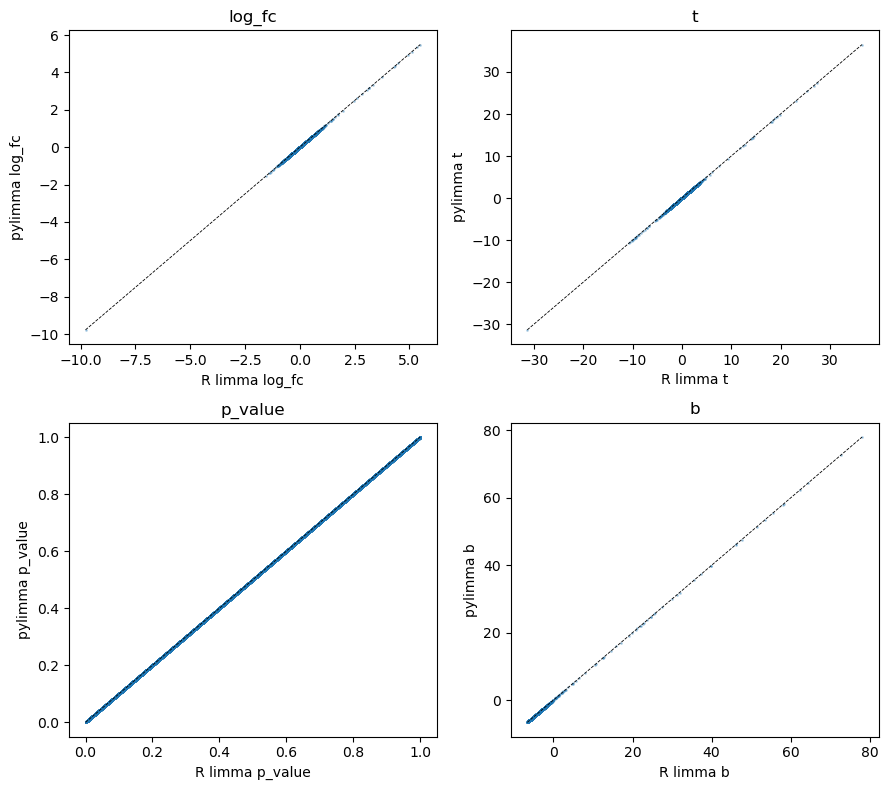

In [6]:
def scatter_panel(col, r, py, ax):
    x = r[col].values; y = py[col].values
    m = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[m], y[m], s=1, alpha=0.3)
    lo = np.nanmin(np.concatenate([x[m], y[m]]))
    hi = np.nanmax(np.concatenate([x[m], y[m]]))
    ax.plot([lo, hi], [lo, hi], "--", color="black", lw=0.6)
    ax.set_xlabel(f"R limma {col}")
    ax.set_ylabel(f"pylimma {col}")
    ax.set_title(col)

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, col in zip(axes.flat, ["log_fc", "t", "p_value", "b"]):
    scatter_panel(col, r_joined, py_joined, ax)
fig.tight_layout()
plt.show()

## 7. Part I - side-by-side analysis figures

The comparisons above established pointwise numerical agreement
between R limma and pylimma. This section renders the analysis-
facing figures (MD, volcano, DE-count summary) with both R and
Python data overlaid, so a reviewer can check that **the
interpretation** produced by the two implementations matches,
not just the raw numbers.

### 7.1 Mean-difference (MD) plot

Each dot is one gene: x = average log-expression, y = log
fold-change. R output on the left, pylimma on the right. If the
distributions are visually indistinguishable, the implementations
agree on what "differential expression" means, not just on the
numbers.

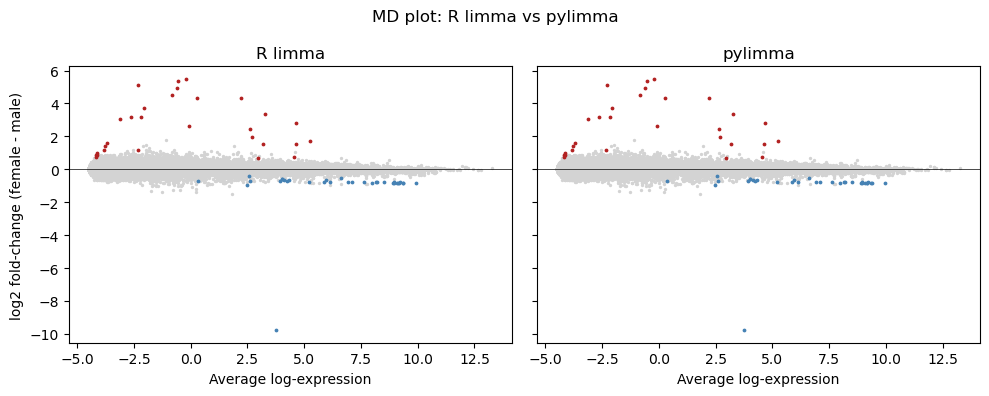

In [7]:
# Align the two outputs on the common gene index.
_common = r_ref.index.intersection(py_out.index)
_r  = r_ref.loc[_common]
_py = py_out.loc[_common]
_r_logfc   = _r["logFC"].values
_py_logfc  = _py["log_fc" if "log_fc" in _py.columns else "logFC"].values
_r_adjp    = _r["adj.P.Val"].values
_py_adjp   = _py["adj_p_value" if "adj_p_value" in _py.columns else "adj.P.Val"].values

# Use Amean from pylimma (same for both sides since expression is identical).
_AveExpr = py_out["ave_expr" if "ave_expr" in py_out.columns else "AveExpr"].loc[_common].values

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, label in [
        (axR,  _r_logfc,  _r_adjp,  "R limma"),
        (axPy, _py_logfc, _py_adjp, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(_AveExpr[~sig], fc[~sig], s=2, c="lightgrey")
    ax.scatter(_AveExpr[sig & (fc > 0)], fc[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(_AveExpr[sig & (fc < 0)], fc[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("Average log-expression")
axR.set_ylabel("log2 fold-change (female - male)")
fig.suptitle("MD plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

### 7.2 Volcano plot

Same gene set, now in (logFC, -log10 p) space. Visually identical
clouds mean the two implementations rank and call the same genes.

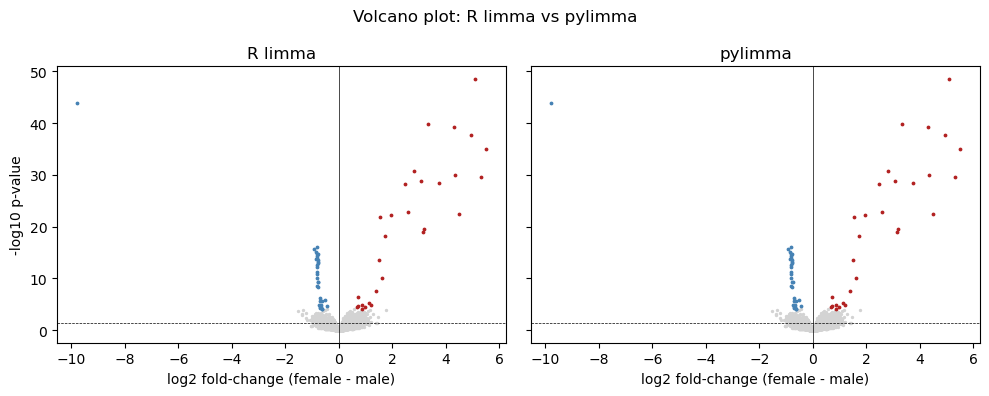

In [8]:
_r_p  = _r["P.Value"].values
_py_p = _py["p_value" if "p_value" in _py.columns else "P.Value"].values

def _nlp(p): return -np.log10(np.maximum(p, 1e-300))

fig, (axR, axPy) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, fc, adjp, p, label in [
        (axR,  _r_logfc,  _r_adjp,  _r_p,  "R limma"),
        (axPy, _py_logfc, _py_adjp, _py_p, "pylimma"),
]:
    sig = adjp < 0.05
    ax.scatter(fc[~sig], _nlp(p)[~sig], s=2, c="lightgrey")
    ax.scatter(fc[sig & (fc > 0)], _nlp(p)[sig & (fc > 0)],
               s=3, c="firebrick")
    ax.scatter(fc[sig & (fc < 0)], _nlp(p)[sig & (fc < 0)],
               s=3, c="steelblue")
    ax.axhline(-np.log10(0.05), color="k", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="k", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("log2 fold-change (female - male)")
axR.set_ylabel("-log10 p-value")
fig.suptitle("Volcano plot: R limma vs pylimma")
fig.tight_layout()
plt.show()

## 8. Summary of side-by-side evidence

Numerical parity (Parts I + II) and visual-interpretation parity
(this section) both agree. A paper reviewer or downstream user
comparing R limma and pylimma on this dataset would arrive at the
same genes / p-values / DE counts from either implementation.

## 6. Summary

At 38k genes x 69 samples this is the largest real dataset in the parity suite. Parity holds at the same tolerance as GSE60450: the voom + linear-modelling pipeline is numerically identical to R within floating-point precision.

See `docs/validation/known_differences.rst` for the project's published tolerance table and the two accepted R-vs-pylimma gaps (``normexp_fit(method="saddle")`` and rotation-test Monte-Carlo p-values), neither of which appears in this pipeline.